# Recitation 2 demo: how fast does the CLT kick in?

The central limit theorem says the standardized sample mean

$$Z_n=\frac{\sqrt{n}\,(\overline{X}_n-\mu)}{\sigma}$$

looks more and more like $\mathcal{N}(0,1)$. How large does $n$ have to be? Here we
draw from the exponential distribution with mean 1, which is skewed, and watch.

Run everything with **Runtime > Run all** (a few seconds), then change the numbers and run again.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
N = 10000                                  # how many sample means per panel

def standardized_means(n, N=N):
    """N standardized means of exponential samples of size n (mu = sigma = 1)."""
    x = rng.exponential(1, size=(N, n))
    return np.sqrt(n) * (x.mean(axis=1) - 1)

z = np.linspace(-4, 4, 200)
phi = np.exp(-z**2 / 2) / np.sqrt(2 * np.pi)      # the N(0,1) density
print("ready")

ready


## The picture

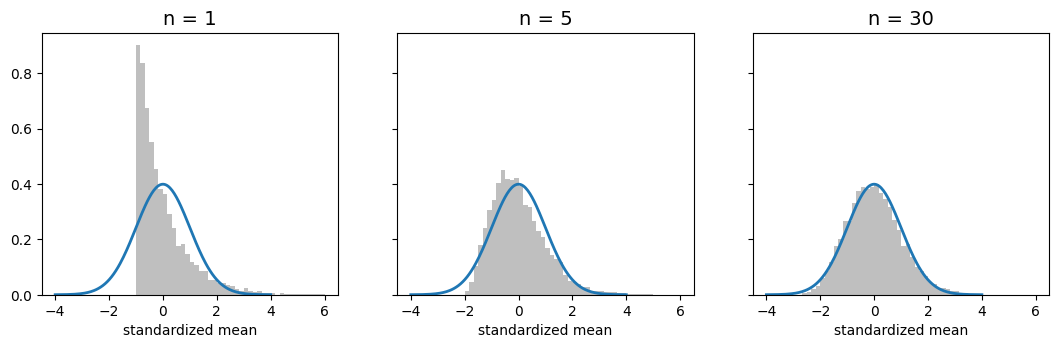

In [2]:
sizes = [1, 5, 30]                         # <- change these

fig, ax = plt.subplots(1, len(sizes), figsize=(13, 3.4), sharey=True)
for k, n in enumerate(sizes):
    ax[k].hist(standardized_means(n), bins=60, range=(-4, 6), density=True, color="0.75")
    ax[k].plot(z, phi, linewidth=2)
    ax[k].set_title(f"n = {n}", fontsize=14)
    ax[k].set_xlabel("standardized mean")
plt.show()

At $n=1$ the histogram *is* the exponential density, shifted: nothing below $-1$, and a
long right tail. At $n=5$ it is bell-shaped but still leans right. At $n=30$ it sits on the
normal curve.

## The tails, which is where the difference lives

In [3]:
for n in sizes:
    Z = standardized_means(n)
    print(f"n = {n:2d}:  P(Z > 1.645) = {np.mean(Z > 1.645):.3f}   "
          f"P(Z < -1.645) = {np.mean(Z < -1.645):.3f}    (normal: 0.050 each)")

n =  1:  P(Z > 1.645) = 0.073   P(Z < -1.645) = 0.000    (normal: 0.050 each)
n =  5:  P(Z > 1.645) = 0.069   P(Z < -1.645) = 0.012    (normal: 0.050 each)
n = 30:  P(Z > 1.645) = 0.058   P(Z < -1.645) = 0.039    (normal: 0.050 each)


The right tail is too heavy and the left tail too light, and both errors shrink as $n$ grows.

## A trap

Checking the fit by counting how often $|Z|>1.96$ looks fine even at $n=1$:

In [4]:
for n in sizes:
    Z = standardized_means(n)
    print(f"n = {n:2d}:  P(|Z| > 1.96) = {np.mean(np.abs(Z) > 1.96):.3f}    (normal: 0.050)")

n =  1:  P(|Z| > 1.96) = 0.051    (normal: 0.050)
n =  5:  P(|Z| > 1.96) = 0.041    (normal: 0.050)
n = 30:  P(|Z| > 1.96) = 0.046    (normal: 0.050)


...because the two errors cancel: too much probability in the right tail, too little in
the left. One-sided tails are the honest check.

## A symmetric distribution needs a much smaller n

Same experiment with the uniform distribution on $[0,1]$, whose skewness is 0:

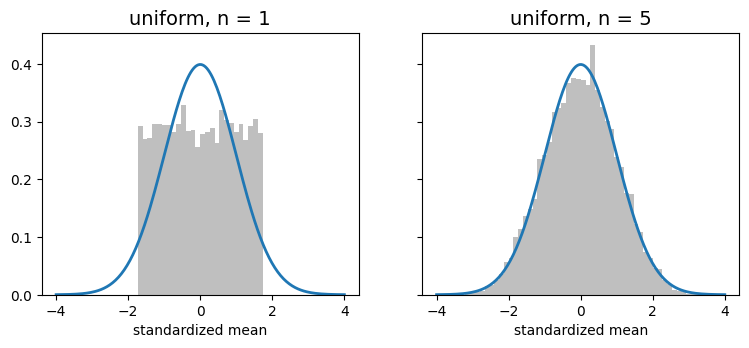

In [5]:
def standardized_means_uniform(n, N=N):
    x = rng.random((N, n))                              # mean 1/2, variance 1/12
    return np.sqrt(n) * (x.mean(axis=1) - 0.5) / np.sqrt(1 / 12)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.4), sharey=True)
for k, n in enumerate([1, 5]):
    ax[k].hist(standardized_means_uniform(n), bins=60, range=(-4, 4), density=True, color="0.75")
    ax[k].plot(z, phi, linewidth=2)
    ax[k].set_title(f"uniform, n = {n}", fontsize=14)
    ax[k].set_xlabel("standardized mean")
plt.show()

Already at $n=5$ it is hard to tell from the normal curve. The exponential needs a larger
$n$ because it is skewed, and the skewness of the sample mean only falls like $2/\sqrt{n}$.
The Berry-Esseen inequality makes this precise: the error is at most a constant times
$\mathbb{E}|X-\mu|^3/(\sigma^3\sqrt{n})$.

---

The same simulation is in this folder as a script in MATLAB, Python, R and Julia
(`clt_exponential.*`), with a fixed seed and the same printout. This notebook is part of
STAN, the code repository for MATH 166 at Tufts University:
<https://github.com/andreasmang/stan>.